In [1]:
import pandas as pd
import pickle
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import easyMPRA as em
from _helper_functions import *

import warnings
warnings.filterwarnings('ignore')

loading libraries...
done!


In [2]:
df=pd.read_pickle('01-Calculate-Enhancer-Activity-Levels/02-generated-tables/endf.sumRnaDivSumDna.splitReps.pd.df').set_index('enhancer-seq',drop=False)
df.head()

,enhancer-seq,pool-sumR/sumD-1-filtNa-Dnotnull,pool-sumR/sumD-2-filtNa-Dnotnull,pool-sumR/sumD-3-filtNa-Dnotnull
enhancer-seq,,,,
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGCAAGTTTTCGAAGAAATAACA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGC...,1.380899,0.000000,1.359589
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGCAAGTTTTCGAAGTTATTTCA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGC...,1.594993,0.000000,0.000000
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTTGCGTTTTCGAAGAAATAACA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTT...,4.488182,1.920774,0.000000
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTTGCGTTTTCGAAGTTATTTCA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTT...,0.754618,0.000000,0.000000
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCGAAATAACTTTCGAAACGCAAGTA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCGAAA...,1.673555,0.000000,1.145072


In [3]:
len(df)

896860

In [4]:
# for establishing dynamic range
for i in ['1','2','3']:
    print(min([i for i in df[f'pool-sumR/sumD-{i}-filtNa-Dnotnull'] if i > 0]))
    print(max(df[f'pool-sumR/sumD-{i}-filtNa-Dnotnull']))

0.0003361723001681187
349.7952601277826
0.0003437869315619499
555.153592707719
0.000780360243609508
750.2183745637852


In [5]:
expdf=pd.read_pickle('01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle').set_index('wt-enhancer-seq',drop=False)
expdf.head()

,enhancer-id,enhancer-sites,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
wt-enhancer-seq,,,,,,,,
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,ORL351560,L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAGATATTAAGATAGGA,ORL108031,L1-G1R-L2-E1F-L3-E2F-L4-G2F-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTCCTATCTTA,ORL414244,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,ORL280162,L1-G1R-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


In [6]:
minActCutoff=0.15

for rep in [1,2,3]:
    # without filtering 
    col=f'pool-sumR/sumD-{rep}-filtNa-Dnotnull'
    df[col+'-log2']=np.log2(df[col])

    # with filtering 
    col=f'pool-sumR/sumD-{rep}-filtNa-Dnotnull'
    
    df[col+f'-minActFilt{minActCutoff}']=df[col].where(df[col]>=minActCutoff,np.NaN)
    df[col+f'-minActFilt{minActCutoff}-log2']=np.log2(df[col+f'-minActFilt{minActCutoff}'])

In [7]:
df=df.replace(np.inf,np.NaN)
df=df.replace(-np.inf,np.NaN)

# Load internal controls

In [8]:
natureCodeDir='../../../000-nature-reviews-code/0-orl/1-mpra-experiment/'
fn=f'{natureCodeDir}reference-files/microscope-controls.tsv'
!head {fn}

Microscope Label	Sequence
Inert	TGCTCACTTGCGTTACCTATTTTTTTCGAAGAAATAACCATCTGAAGCTCAAATATTATTTGCTTA
Inert	CATCTGAAGCTCGTTATTTCTGCTCCCTATTTTTTTCGAAATTTGCTTTAACTTGCGTAAATATTA
Neural	CATCTGAAGCTCACGGAAGTTGCTCGTTATCTCTTTCGAACCTATCTTATTTCCTTTAAGATATTA
Neural	TTTCGAAAATATCTCCTATCTTCATCTGAAGCTCGTTATCTCTAAAGGAAATTGCTCACGGAAGTA
Inert	AAGATAGGTGCTCAAGGAAATTAAGATATTTTTCGAAGAGATAACCATCTGAAGCTCACTTCCGTA
Inert	TTTCGAAATTTCCTTCATCTGAAGCTCGAGATAACACGGAAGTTGCTCAATATCTTACCTATCTTA
Neural	CATCTGAAGCTCAAGATAGGGAGATAACTGCTCACGGAAGTTTTCGAAAATATCTTAAAGGAAATA
Inert	CATCTGAAGCTCATTTGCTTTTTCGAACCTATTTTTGCTCAATATTTACGCAAGTTAGAAATAACA
Neural	AGATATTTGCTCGAGATAACCATCTGAAGCTCACTTCCGTTAATTTCCTTTTTCGAAAAGATAGGA


In [9]:
# map sequence to control ref info
seq2label={}
for label,sequence in read_tsv(fn,pc=False,header=True):
    seq2label[sequence]=label
dprint(seq2label)

TGCTCACTTGCGTTACCTATTTTTTTCGAAGAAATAACCATCTGAAGCTCAAATATTATTTGCTTA Inert


# Plot internal controls across 3 reps

In [10]:
activityCol=f'pool-sumR/sumD-[[rep]]-filtNa-Dnotnull-minActFilt{minActCutoff}-log2'


# plot controls
swarmc2v={c:[] for c in ['seq','rep','act','label']}
for seq,label in seq2label.items():

    for rep in ['1','2','3']:
        
        acol=activityCol.replace('[[rep]]',rep)
        act=df.at[seq,acol]

        if act>1 or act<0:
        
            swarmc2v['seq'].append(seq)
            swarmc2v['act'].append(act)
            swarmc2v['rep'].append(rep)
            swarmc2v['label'].append(label)
            
swarmdf=pd.DataFrame(swarmc2v)

In [11]:
allDetectedEns=set(df.index)

In [12]:
inerts=expdf.loc[expdf['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']<0,'wt-enhancer-seq'].tolist()

In [13]:
actives=expdf.loc[expdf['enhancer-dependent-gata-ets']==1,'wt-enhancer-seq'].tolist()

In [14]:
inerts=list(set(inerts)&allDetectedEns)
actives=list(set(actives)&allDetectedEns)

In [15]:
df.head()

,enhancer-seq,pool-sumR/sumD-1-filtNa-Dnotnull,pool-sumR/sumD-2-filtNa-Dnotnull,pool-sumR/sumD-3-filtNa-Dnotnull,pool-sumR/sumD-1-filtNa-Dnotnull-log2,pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15,pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2,pool-sumR/sumD-2-filtNa-Dnotnull-log2,pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15,pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2,pool-sumR/sumD-3-filtNa-Dnotnull-log2,pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15,pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2
enhancer-seq,,,,,,,,,,,,,
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGCAAGTTTTCGAAGAAATAACA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGC...,1.380899,0.000000,1.359589,0.465608,1.380899,0.465608,NaN,NaN,NaN,0.443170,1.359589,0.443170
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGCAAGTTTTCGAAGTTATTTCA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGC...,1.594993,0.000000,0.000000,0.673550,1.594993,0.673550,NaN,NaN,NaN,NaN,NaN,NaN
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTTGCGTTTTCGAAGAAATAACA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTT...,4.488182,1.920774,0.000000,2.166131,4.488182,2.166131,0.941688,1.920774,0.941688,NaN,NaN,NaN
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTTGCGTTTTCGAAGTTATTTCA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTT...,0.754618,0.000000,0.000000,-0.406181,0.754618,-0.406181,NaN,NaN,NaN,NaN,NaN,NaN
AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCGAAATAACTTTCGAAACGCAAGTA,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCGAAA...,1.673555,0.000000,1.145072,0.742916,1.673555,0.742916,NaN,NaN,NaN,0.195438,1.145072,0.195438


In [16]:
len(df)

896860

In [17]:
inertrepdf=df.loc[inerts,:]
activerepdf=df.loc[actives,:]
len(inertrepdf),len(activerepdf)

(143775, 52101)

(-3.0, 8.0)

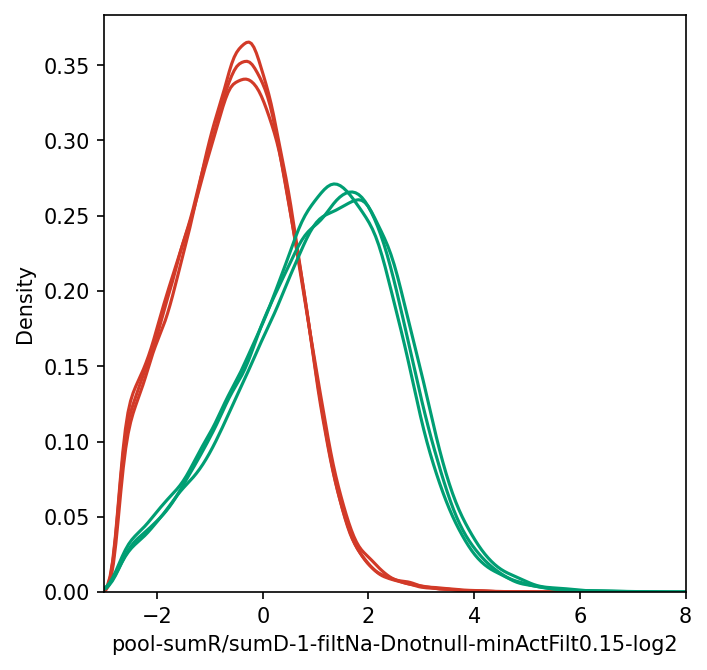

In [18]:
fig,ax=quickfig()
data=[
(inertrepdf['pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2'],cb['orangenature']),
(inertrepdf['pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2'],cb['orangenature']),
(inertrepdf['pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2'],cb['orangenature']),
(activerepdf['pool-sumR/sumD-1-filtNa-Dnotnull-minActFilt0.15-log2'],cb['green']),
(activerepdf['pool-sumR/sumD-2-filtNa-Dnotnull-minActFilt0.15-log2'],cb['green']),
(activerepdf['pool-sumR/sumD-3-filtNa-Dnotnull-minActFilt0.15-log2'],cb['green'])
]

for di,ci in data:
    sns.kdeplot(di, color=ci)  # Or 'stepfilled' with alpha=1

ax.set_xlim(-3,8)


In [19]:
swarmdf['xdummy']=0

Text(40.083333333333336, 0.5, 'enhancer activity')

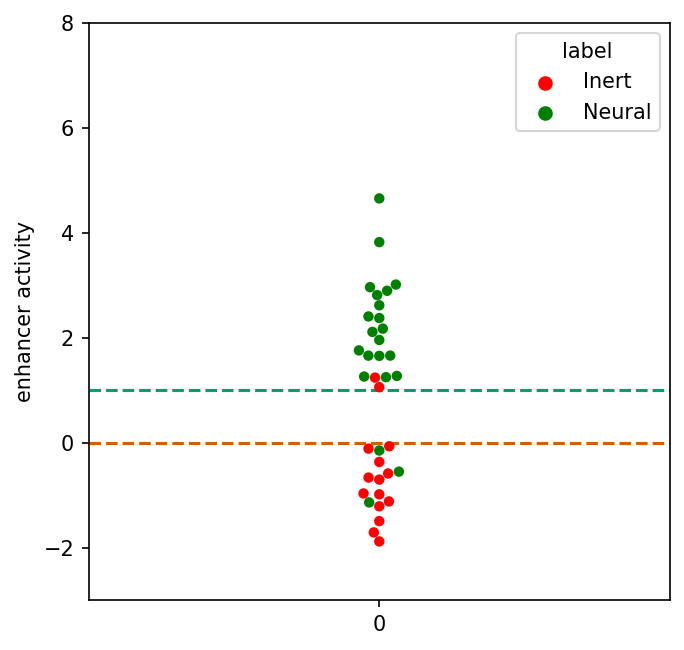

In [20]:
fig,ax=quickfig()

sns.swarmplot(swarmdf,x='xdummy',y='act',hue='label',palette={'Inert':'red','Neural':'green'})
ax.set_ylim(-3,8)

ax.axhline(0,color=cb['red'],ls='--')
ax.axhline(1,color=cb['green'],ls='--')

ax.set_xlabel('')
ax.set_ylabel('enhancer activity')